In [1]:
import torch
import timm
import os
import random
import numpy as np

IS_KAGGLE = os.path.exists("/kaggle")

if IS_KAGGLE:
    BASE_DIR = "/kaggle/working"
else:
    BASE_DIR = "."

RUNS_DIR    = os.path.join(BASE_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)

def save_siamnet_weights(model, run_name: str) -> str:
    """Full SiamNet state_dict (encoder + head) under RUNS_DIR."""
    path = os.path.join(RUNS_DIR, f"{run_name}_state.pt")
    torch.save(model.state_dict(), path)
    return path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

g = torch.Generator()
g.manual_seed(42)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [ ]:
!nvidia-smi

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Publication style: colorblind-safe Okabe-Ito palette, serif fonts, vector PDF.
PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#F0E442", "#56B4E9"]

mpl.rcParams.update({
    "font.family":         "serif",
    "font.size":           11,
    "axes.labelsize":      12,
    "axes.titlesize":      13,
    "axes.titleweight":    "bold",
    "legend.fontsize":     10,
    "legend.frameon":      False,
    "xtick.labelsize":     10,
    "ytick.labelsize":     10,
    "figure.dpi":          120,
    "savefig.dpi":         300,
    "savefig.bbox":        "tight",
    "axes.grid":           True,
    "grid.alpha":          0.25,
    "grid.linestyle":      "--",
    "lines.linewidth":     1.8,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=PALETTE)


def save_figure(fig, name):
    """Save a figure as both PDF (vector, paper-ready) and PNG (preview)."""
    pdf_path = os.path.join(RUNS_DIR, f"{name}.pdf")
    png_path = os.path.join(RUNS_DIR, f"{name}.png")
    fig.savefig(pdf_path)
    fig.savefig(png_path)
    return pdf_path, png_path


# Augs

In [ ]:
import torchvision.transforms as transforms
from torchvision.transforms import v2, functional
import torch
import numpy as np
import random
import string
import io
from PIL import Image, ImageDraw, ImageFont


class RandomCompose(object):
    """Apply each transform with probability p (independently). Works on PIL or Tensor."""
    def __init__(self, transforms, p=0.3):
        self.p = p
        self.transforms = transforms

    def __call__(self, x):
        for t in self.transforms:
            if random.random() < self.p:
                x = t(x)
        return x


# === D4: tensor-native rotations 90/180/270 ===

class RandomRotation90Tensor(object):
    def __call__(self, x):
        k = random.randint(1, 3)
        return torch.rot90(x, k, dims=(-2, -1))


# === Gaussian noise (works on uint8 or float tensors) ===

class GaussianNoiseTensor(object):
    def __init__(self, std_range=(0.01, 0.05)):
        self.std_range = std_range

    def __call__(self, x):
        std = random.uniform(*self.std_range)
        if x.dtype == torch.uint8:
            std *= 255.0
            noise = torch.randn_like(x, dtype=torch.float32) * std
            return torch.clamp(x.float() + noise, 0, 255).to(torch.uint8)
        return torch.clamp(x + torch.randn_like(x) * std, 0, 1)


# === Watermark (kept PIL-based; text rendering is awkward on tensors) ===

class RandomWatermark(object):
    def __init__(self, alpha_range=(0.1, 0.4)):
        self.alpha_range = alpha_range

    def __call__(self, img):
        overlay = Image.new('RGBA', img.size, (0, 0, 0, 0))
        draw = ImageDraw.Draw(overlay)
        text = ''.join(random.choices(string.ascii_uppercase, k=random.randint(2, 5)))
        font_size = max(8, img.size[0] // 3)
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", font_size)
        except (OSError, IOError):
            font = ImageFont.load_default()
        x = random.randint(0, max(0, img.size[0] - font_size))
        y = random.randint(0, max(0, img.size[1] - font_size))
        alpha = int(255 * random.uniform(*self.alpha_range))
        color = (
            random.randint(100, 255),
            random.randint(100, 255),
            random.randint(100, 255),
            alpha
        )
        draw.text((x, y), text, fill=color, font=font)
        return Image.alpha_composite(img.convert('RGBA'), overlay).convert('RGB')


# Какую группу геометрических аугментаций добавлять поверх блока P в augmented loader.
#   'none' -- только photometric (для эквивариантных энкодеров).
#   'd4'   -- photometric + R90/180/270, HFlip, VFlip.
#   'se2'  -- photometric + непрерывный поворот в [0, 360) и непрерывный сдвиг.
GEOMETRIC_GROUP = 'se2'


def _identity_pipeline():
    """PIL -> uint8 tensor -> 32x32 -> float32."""
    return v2.Compose([
        v2.PILToTensor(),
        v2.Resize((32, 32), antialias=True),
        v2.ToDtype(torch.float32, scale=True),
    ])


def get_augmentations(group=None, aug=True):
    """Build augmentation pipeline. Returns float32 (C,H,W) tensors of size 32x32."""
    if not aug:
        return _identity_pipeline()

    if group is None:
        group = GEOMETRIC_GROUP

    # PIL stage: watermark draws text via ImageDraw (no tensor equivalent).
    pil_ops = [RandomWatermark(alpha_range=(0.1, 0.4))]

    # Tensor stage (operates on uint8 CHW tensors after PILToTensor).
    photometric_t = [
        v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        v2.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        GaussianNoiseTensor(std_range=(0.01, 0.05)),
        v2.JPEG(quality=(10, 50)),
    ]
    d4_block = [
        RandomRotation90Tensor(),
        v2.RandomHorizontalFlip(p=1.0),
        v2.RandomVerticalFlip(p=1.0),
    ]
    se2_block = [
        v2.RandomRotation(degrees=(0, 360), expand=False),
        v2.RandomAffine(degrees=0, translate=(0.2, 0.2)),
    ]

    if group == 'none':
        tensor_ops = photometric_t
    elif group == 'd4':
        tensor_ops = photometric_t + d4_block
    elif group == 'se2':
        tensor_ops = photometric_t + se2_block
    else:
        raise ValueError(f"unknown group {group!r}; expected one of 'none', 'd4', 'se2'")

    return v2.Compose([
        RandomCompose(pil_ops, p=0.3),
        v2.PILToTensor(),
        RandomCompose(tensor_ops, p=0.3),
        v2.Resize((32, 32), antialias=True),
        v2.ToDtype(torch.float32, scale=True),
    ])


# === PIL-based companions used by DomainNet per-class evaluation ===
# Eval pipeline operates on PIL images one at a time, so these are kept as
# simple PIL implementations even though training uses the v2 tensor versions
# for speed.

class GaussianNoise(object):
    def __init__(self, std_range=(0.01, 0.05)):
        self.std_range = std_range
    def __call__(self, img):
        img_np = np.array(img).astype(np.float32) / 255.0
        std = random.uniform(*self.std_range)
        noise = np.random.normal(0, std, img_np.shape).astype(np.float32)
        img_np = np.clip(img_np + noise, 0, 1)
        return Image.fromarray((img_np * 255).astype(np.uint8))


class JPEGCompression(object):
    def __init__(self, quality_range=(10, 50)):
        self.quality_range = quality_range
    def __call__(self, img):
        quality = random.randint(*self.quality_range)
        buffer = io.BytesIO()
        img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        return Image.open(buffer).convert('RGB')


class RandomTranslate(object):
    def __init__(self, max_fraction=0.2, fill=0):
        self.max_fraction = max_fraction
        self.fill = fill
    def __call__(self, img):
        w, h = img.size
        dx = int(round(random.uniform(-self.max_fraction, self.max_fraction) * w))
        dy = int(round(random.uniform(-self.max_fraction, self.max_fraction) * h))
        return functional.affine(
            img, angle=0.0, translate=(dx, dy), scale=1.0, shear=(0.0, 0.0),
            interpolation=transforms.InterpolationMode.BILINEAR, fill=self.fill,
        )


# Models

In [ ]:
from timm.models.vision_transformer import VisionTransformer
import torch.nn as nn

class ViTEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = VisionTransformer(
            img_size=32,           # Стандартный размер входного изображения для предобученных весов
            patch_size=4,          # Размер патча (ViT-.../16)
            in_chans=3,
            num_classes = 0,
            embed_dim=192,          # Ключевой параметр: скрытая размерность для Tiny
            depth=12,               # Количество слоёв трансформера
            num_heads=3,            # Количество голов внимания (192 / 64 = 3)
            mlp_ratio=4.0,          # Соотношение размера MLP к embed_dim (192 * 4 = 768)
            class_token=True,       # Использовать классификационный токен
            global_pool='token',    # Использовать class token для классификации
        )
        self.feature_dim = 192

    def forward(self, x):
        return self.backbone(x)


In [4]:
!git clone -q https://github.com/davnords/octic-vits.git

import sys
sys.path.insert(0, "octic-vits")

In [5]:
from octic_vits import OcticVisionTransformer
import os
import torch.nn as nn

class OcticViTEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_dim = 192

        self.backbone = OcticVisionTransformer(
            img_size=32,
            patch_size=4,
            embed_dim=192,
            depth=12,
            num_heads=3,
            invariant=True,
            num_classes=0,
        )

    def forward(self, x):
        out = self.backbone(x)
        return out


In [ ]:
import sys
import os
import torch.nn as nn

_harm_paths = [
    os.path.join(BASE_DIR, "newcode"),
    BASE_DIR,
    os.path.join(os.getcwd(), "newcode"),
    os.getcwd(),
]
for _p in _harm_paths:
    if _p and os.path.isfile(os.path.join(_p, "harmformer_encoder.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        break

from harmformer_encoder import HarmformerEncoder


class HarmformerViTEncoder(nn.Module):
    """Tiny Harmformer; same embedding dim as ViT/Octic (192)."""

    def __init__(self):
        super().__init__()
        self.backbone = HarmformerEncoder(
            img_size=32,
            stem_channels=[16, 32],
            encoder_dim=64,       # feature_dim = 3 * 64 = 192
            encoder_depth=4,
            num_heads=4,
        )
        self.feature_dim = self.backbone.feature_dim

    def forward(self, x):
        return self.backbone(x)


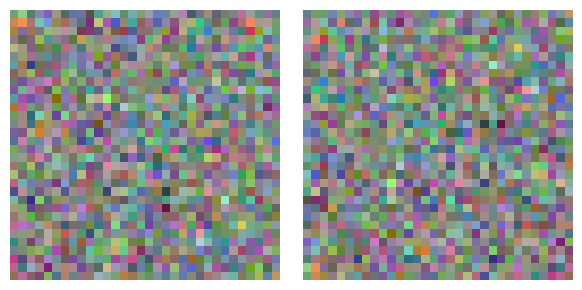

True


In [6]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

enc = ViTEncoder().to(device)
enc.eval()

enc_oc = OcticViTEncoder().to(device)
enc_oc.eval()

enc_hf = HarmformerViTEncoder().to(device)
enc_hf.eval()

img = torch.randn(1, 3, 32, 32).to(device)
angle = 90

img_rot = functional.rotate(
    img,
    angle,
    expand=True)

img_rot32 = F.interpolate(img_rot, size=(32, 32), mode="bilinear", align_corners=False)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, im in zip(axes, [img, img_rot]):
    img_np = im.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    ax.imshow(img_np)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("OcticViT allclose(img, img_rot):", torch.allclose(enc_oc(img), enc_oc(img_rot)))
print("Harmformer cos(emb, emb_rot32):", F.cosine_similarity(enc_hf(img), enc_hf(img_rot32), dim=-1).item())

In [7]:
class HeadModel(nn.Module):
    """Advanced head that accepts pre-computed difference AND product embeddings.
    
    This architecture is designed to work with pre-computed difference vectors AND element-wise products.
    The inputs should already be in the format:
    - diff_embeddings: [|emb1 - emb2|] for all pairs
    - product_embeddings: [emb1 * emb2] for all pairs
    """
    
    def __init__(self, feature_dim, dropout_rate=0.1):
        """
        Args:
            feature_dim (int): Dimension of input feature vectors
            dropout_rate (float): Dropout probability. Defaults to 0.1.
        """
        super().__init__()
        
        self.diff_pathway = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.product_pathway = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate)
        )
        
        self.fusion = nn.Sequential(
            nn.Linear(2 * feature_dim, feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(feature_dim, 1),
            nn.Sigmoid()
        )
    
    def forward(self, diff_embeddings, product_embeddings):
        """
        Forward pass with pre-computed difference and product features.
        
        Args:
            diff_embeddings: Tensor of shape [batch_size, feature_dim] 
                representing pre-computed |embedding1 - embedding2|
            product_embeddings: Tensor of shape [batch_size, feature_dim]
                representing pre-computed element-wise product of embeddings
                
        Returns:
            Tensor of shape [batch_size, 1] with similarity probabilities (after sigmoid)
        """
        diff_features = self.diff_pathway(diff_embeddings)
        product_features = self.product_pathway(product_embeddings)
        
        combined = torch.cat([diff_features, product_features], dim=1)
        return self.fusion(combined)


In [8]:
class SiamNet(nn.Module):
    def __init__(self, encoder):
        super(SiamNet, self).__init__()
        self.encoder = encoder

        self.head = HeadModel(self.encoder.feature_dim)

    def forward(self, batch1: torch.Tensor, batch2: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the siamese network.

        Args:
            batch1: First batch of images [batch_size, channels, height, width]
            batch2: Second batch of images [batch_size, channels, height, width]

        Returns:
            torch.Tensor: Similarity matrix [batch_size1, batch_size2]
        """
        emb1 = self.encoder(batch1)
        emb2 = self.encoder(batch2)

        batch_size1, batch_size2 = emb1.size(0), emb2.size(0)
        emb1_expanded = emb1.unsqueeze(1).expand(-1, batch_size2, -1)
        emb2_expanded = emb2.unsqueeze(0).expand(batch_size1, -1, -1)

        # Pre-compute the difference and product vectors
        diff_embeddings = torch.abs(emb1_expanded - emb2_expanded)
        product_embeddings = emb1_expanded * emb2_expanded
        
        # Reshape for head model
        diff_embeddings = diff_embeddings.view(-1, self.encoder.feature_dim)
        product_embeddings = product_embeddings.view(-1, self.encoder.feature_dim)

        # Pass pre-computed features to the head
        logits = self.head(diff_embeddings, product_embeddings)
            
        logits = logits.view(batch_size1, batch_size2)
        return logits


In [9]:
model = SiamNet(enc_oc)
model.to(device)
model.eval()
model(img, img_rot), model(img, img)

(tensor([[0.5174]], device='cuda:0', grad_fn=<ViewBackward0>),
 tensor([[0.5174]], device='cuda:0', grad_fn=<ViewBackward0>))

# Dataset

In [ ]:
import os
import glob
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import v2
from PIL import Image
import torch


def _resolve_coco_root() -> str:
    candidates = [
        "/kaggle/input/coco-2017-dataset/coco2017/train2017",
        "/kaggle/input/coco2017/train2017",
        os.path.join(BASE_DIR, "data", "coco2017", "train2017"),
        os.path.join(BASE_DIR, "data", "train2017"),
    ]
    for c in candidates:
        if os.path.isdir(c):
            return c
    raise FileNotFoundError(
        "COCO 2017 train2017 not found. Tried: " + ", ".join(candidates)
    )


class COCO2017Dataset(Dataset):
    """Pairs for siamese training over COCO 2017.

    Each __getitem__ returns (anchor, augmented_view) as float32 tensors of shape
    (3, 32, 32). The augmentation pipeline is mostly tensor-native (torchvision v2),
    so JPEG, ColorJitter, GaussianBlur and rotations run on uint8 tensors instead of
    PIL images.
    """

    def __init__(self, train=True, aug=False, group=None, root=None,
                 val_fraction=0.05, seed=42):
        self.aug = aug
        self.augment = get_augmentations(group=group, aug=aug)
        # Pre-resize source to keep PIL watermark draw fast.
        self.pre_resize = transforms.Resize((96, 96))
        self.identity = v2.Compose([
            v2.PILToTensor(),
            v2.Resize((32, 32), antialias=True),
            v2.ToDtype(torch.float32, scale=True),
        ])
        self.root = root if root is not None else _resolve_coco_root()
        files = sorted(glob.glob(os.path.join(self.root, "*.jpg")))
        if not files:
            raise RuntimeError(f"no .jpg files under {self.root}")
        rng = random.Random(seed)
        rng.shuffle(files)
        cut = int(len(files) * (1 - val_fraction))
        self.files = files[:cut] if train else files[cut:]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx])
        # Decode JPEG at lower resolution where possible (~8x faster on full COCO frames).
        try:
            img.draft("RGB", (192, 192))
        except Exception:
            pass
        img = img.convert("RGB")
        img = self.pre_resize(img)
        anchor = self.identity(img)
        view = self.augment(img) if self.aug else self.identity(img)
        return anchor, view


In [ ]:
# Per-paper protocol loaders. Equivariant encoders see only the photometric block;
# the augmented ViT-Tiny/16 baseline sees photometric + the group block matched to the
# comparison. The validation loader uses the photometric block only so that validation
# curves are comparable across runs.

train_loader_photometric = DataLoader(
    COCO2017Dataset(train=True, aug=True, group='none'),
    batch_size=128, shuffle=True, num_workers=6,
    pin_memory=True, drop_last=True,
    persistent_workers=True, prefetch_factor=4,
    worker_init_fn=seed_worker, generator=g,
)

train_loader_d4 = DataLoader(
    COCO2017Dataset(train=True, aug=True, group='d4'),
    batch_size=128, shuffle=True, num_workers=6,
    pin_memory=True, drop_last=True,
    persistent_workers=True, prefetch_factor=4,
    worker_init_fn=seed_worker, generator=g,
)

train_loader_se2 = DataLoader(
    COCO2017Dataset(train=True, aug=True, group='se2'),
    batch_size=128, shuffle=True, num_workers=6,
    pin_memory=True, drop_last=True,
    persistent_workers=True, prefetch_factor=4,
    worker_init_fn=seed_worker, generator=g,
)

test_loader = DataLoader(
    COCO2017Dataset(train=False, aug=True, group='none'),
    batch_size=128, shuffle=False, num_workers=6,
    pin_memory=True, drop_last=True,
    persistent_workers=True, prefetch_factor=4,
    worker_init_fn=seed_worker, generator=g,
)


# Regularizer

In [12]:
class ContrastiveLoss(torch.nn.Module):
    def __init__(self, margin=0.5):
        super().__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        # label: 1 = same class, 0 = different class
        D = torch.norm(emb1 - emb2, p=2, dim=1)  # L2 норма
        pos = label * D ** 2
        neg = (1 - label) * torch.clamp(self.margin - D, min=0) ** 2
        return (pos + neg).mean()

# Train

In [13]:
from torchmetrics import MetricCollection
from torchmetrics.classification import (
    BinaryAccuracy, BinaryF1Score, BinaryRecall,
    BinaryPrecision, BinarySpecificity
)
from tqdm import tqdm
from torch.amp import autocast, GradScaler

# Enable fast TF32 matmuls on V100/A100.
torch.set_float32_matmul_precision("high")


def make_metrics(device):
    return MetricCollection({
        'accuracy':    BinaryAccuracy(),
        'f1':          BinaryF1Score(),
        'recall':      BinaryRecall(),
        'precision':   BinaryPrecision(),
        'specificity': BinarySpecificity(),
    }).to(device)


def train_model(model, train_loader, test_loader, optimizer, scheduler,
                num_epochs, device, regularizer=None, lam=0.05,
                log_dir='runs'):
    scaler = GradScaler('cuda', enabled=(device.type == 'cuda'))
    history = {
        'train_loss': [], 'val_loss': [],
        'train_accuracy': [], 'val_accuracy': [],
        'train_f1': [], 'val_f1': [],
        'train_recall': [], 'val_recall': [],
        'train_precision': [], 'val_precision': [],
        'train_fpr': [], 'val_fpr': [],
        'lr': [],
    }

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_total = 0
        train_metrics = make_metrics(device)

        for batch1, batch2 in tqdm(train_loader, desc=f'Train {epoch+1}/{num_epochs}'):
            batch1, batch2 = batch1.to(device, non_blocking=True), batch2.to(device, non_blocking=True)
            batch_size = batch1.size(0)
            pairs_batch_size = batch_size ** 2

            optimizer.zero_grad(set_to_none=True)

            with autocast('cuda', enabled=(device.type == 'cuda'), dtype=torch.float16):
                embs1 = model.encoder(batch1)
                embs2 = model.encoder(batch2)

                embs1_expanded = embs1.unsqueeze(1).expand(-1, batch_size, -1)
                embs2_expanded = embs2.unsqueeze(0).expand(batch_size, -1, -1)

                diff_embeddings = torch.abs(embs1_expanded - embs2_expanded).view(-1, model.encoder.feature_dim)
                product_embeddings = (embs1_expanded * embs2_expanded).view(-1, model.encoder.feature_dim)

                probabilities = model.head(diff_embeddings, product_embeddings).view(-1)

            # Compute losses in fp32 for stability (BCE on sigmoid + L2-contrastive).
            probabilities = probabilities.float()
            labels = torch.eye(batch_size, device=device).view(-1)
            weight = torch.full_like(labels, 0.7)
            weight[labels == 1] = 0.3
            loss = torch.nn.functional.binary_cross_entropy(probabilities, labels, weight=weight)

            if regularizer is not None:
                embs1_all = embs1_expanded.reshape(-1, embs1.size(-1)).float()
                embs2_all = embs2_expanded.reshape(-1, embs2.size(-1)).float()
                contrastive_loss = regularizer(embs1_all, embs2_all, labels)
                total_loss = loss + lam * contrastive_loss
            else:
                total_loss = loss

            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += total_loss.item() * pairs_batch_size
            train_total += pairs_batch_size
            train_metrics.update(probabilities.detach(), labels.int())

        scheduler.step()
        tm = train_metrics.compute()
        train_metrics.reset()
        train_loss /= train_total
        train_fpr = 1 - float(tm['specificity'])

        model.eval()
        val_loss = 0.0
        val_total = 0
        val_metrics = make_metrics(device)

        with torch.no_grad():
            for batch1, batch2 in tqdm(test_loader, desc=f'Val {epoch+1}/{num_epochs}'):
                batch1, batch2 = batch1.to(device, non_blocking=True), batch2.to(device, non_blocking=True)
                batch_size = batch1.size(0)
                pairs_batch_size = batch_size ** 2

                with autocast('cuda', enabled=(device.type == 'cuda'), dtype=torch.float16):
                    embs1 = model.encoder(batch1)
                    embs2 = model.encoder(batch2)

                    embs1_expanded = embs1.unsqueeze(1).expand(-1, batch_size, -1)
                    embs2_expanded = embs2.unsqueeze(0).expand(batch_size, -1, -1)

                    diff_embeddings = torch.abs(embs1_expanded - embs2_expanded).view(-1, model.encoder.feature_dim)
                    product_embeddings = (embs1_expanded * embs2_expanded).view(-1, model.encoder.feature_dim)

                    probabilities = model.head(diff_embeddings, product_embeddings).view(-1)
                probabilities = probabilities.float()

                labels = torch.eye(batch_size, device=device).view(-1)

                weight = torch.full_like(labels, 0.1)
                weight[labels == 1] = 0.9

                loss = torch.nn.functional.binary_cross_entropy(probabilities, labels, weight=weight)

                if regularizer is not None:
                    embs1_all = embs1_expanded.reshape(-1, embs1.size(-1))
                    embs2_all = embs2_expanded.reshape(-1, embs2.size(-1))
                    contrastive_loss = regularizer(embs1_all, embs2_all, labels)
                    total_loss = loss + lam * contrastive_loss
                else:
                    total_loss = loss

                val_loss += total_loss.item() * pairs_batch_size
                val_total += pairs_batch_size
                val_metrics.update(probabilities, labels.int())

        vm = val_metrics.compute()
        val_metrics.reset()
        val_loss /= val_total
        val_fpr = 1 - float(vm['specificity'])

        current_lr = optimizer.param_groups[0]['lr']

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.4f}, '
              f'Train Acc: {tm["accuracy"]:.4f}, '
              f'Train F1: {tm["f1"]:.4f}, '
              f'Train Recall: {tm["recall"]:.4f}, '
              f'Train Prec: {tm["precision"]:.4f}, '
              f'Train FPR: {train_fpr:.4f}, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Acc: {vm["accuracy"]:.4f}, '
              f'Val F1: {vm["f1"]:.4f}, '
              f'Val Recall: {vm["recall"]:.4f}, '
              f'Val Prec: {vm["precision"]:.4f}, '
              f'Val FPR: {val_fpr:.4f}, '
              f'LR: {current_lr}')

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        for m in ('accuracy', 'f1', 'recall', 'precision'):
            history[f'train_{m}'].append(float(tm[m]))
            history[f'val_{m}'].append(float(vm[m]))
        history['train_fpr'].append(train_fpr)
        history['val_fpr'].append(val_fpr)
        history['lr'].append(current_lr)

    return history

In [14]:
all_histories = {}

# Per-paper experiment

Two per-group comparisons, four training runs in total. Equivariant encoders are trained with the photometric block only; the ViT-Tiny/16 baseline is trained with the photometric block plus the geometric block matched to the symmetry group of the comparison.


## Reference baseline (no geometric augmentations)


### ViT-Tiny/16 + photometric block only


In [ ]:
model_vit_p = SiamNet(ViTEncoder())
model_vit_p.to(device)

optimizer = torch.optim.AdamW(model_vit_p.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.5)

history = train_model(
    model_vit_p, train_loader_photometric, test_loader,
    optimizer, scheduler, num_epochs=20,
    device=device, regularizer=ContrastiveLoss(margin=0.5)
)
all_histories['vit_tiny_photometric'] = history
_p = save_siamnet_weights(model_vit_p, "vit_tiny_photometric")
print(f"Saved weights: {_p}")
del model_vit_p
torch.cuda.empty_cache()


## Comparison 1: $G = D_4$


### ViT-Tiny/16 + photometric + $D_4$ augmentations


In [ ]:
model_vit_d4 = SiamNet(ViTEncoder())
model_vit_d4.to(device)

optimizer = torch.optim.AdamW(model_vit_d4.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.5)

history = train_model(
    model_vit_d4, train_loader_d4, test_loader,
    optimizer, scheduler, num_epochs=20,
    device=device, regularizer=ContrastiveLoss(margin=0.5)
)
all_histories['vit_tiny_d4_augs'] = history
_p = save_siamnet_weights(model_vit_d4, "vit_tiny_d4_augs")
print(f"Saved weights: {_p}")
del model_vit_d4
torch.cuda.empty_cache()


### Octic ViT (photometric block only)


In [ ]:
model_octic_p = SiamNet(OcticViTEncoder())
model_octic_p.to(device)

optimizer = torch.optim.AdamW(model_octic_p.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.5)

history = train_model(
    model_octic_p, train_loader_photometric, test_loader,
    optimizer, scheduler, num_epochs=20,
    device=device, regularizer=ContrastiveLoss(margin=0.5)
)
all_histories['octic_photometric'] = history
_p = save_siamnet_weights(model_octic_p, "octic_photometric")
print(f"Saved weights: {_p}")
del model_octic_p
torch.cuda.empty_cache()


## Comparison 2: $G = SE(2)$


### ViT-Tiny/16 + photometric + $SE(2)$ augmentations


In [ ]:
model_vit_se2 = SiamNet(ViTEncoder())
model_vit_se2.to(device)

optimizer = torch.optim.AdamW(model_vit_se2.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.5)

history = train_model(
    model_vit_se2, train_loader_se2, test_loader,
    optimizer, scheduler, num_epochs=20,
    device=device, regularizer=ContrastiveLoss(margin=0.5)
)
all_histories['vit_tiny_se2_augs'] = history
_p = save_siamnet_weights(model_vit_se2, "vit_tiny_se2_augs")
print(f"Saved weights: {_p}")
del model_vit_se2
torch.cuda.empty_cache()


### Harmformer (photometric block only)


In [ ]:
model_harm_p = SiamNet(HarmformerViTEncoder())
model_harm_p.to(device)

optimizer = torch.optim.AdamW(model_harm_p.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.5)

history = train_model(
    model_harm_p, train_loader_photometric, test_loader,
    optimizer, scheduler, num_epochs=20,
    device=device, regularizer=ContrastiveLoss(margin=0.5)
)
all_histories['harmformer_photometric'] = history
_p = save_siamnet_weights(model_harm_p, "harmformer_photometric")
print(f"Saved weights: {_p}")
del model_harm_p
torch.cuda.empty_cache()


## Training history summary


In [ ]:
# Training-history summary across the four paper-aligned runs.
RUNS_FOR_HISTORY = [
    ("vit_tiny_photometric",   "ViT-Tiny/16 (photometric)"),
    ("vit_tiny_d4_augs",       "ViT-Tiny/16 + $D_4$ augs"),
    ("octic_photometric",      "Octic ViT (photometric)"),
    ("vit_tiny_se2_augs",      "ViT-Tiny/16 + $SE(2)$ augs"),
    ("harmformer_photometric", "Harmformer (photometric)"),
]
METRIC_GRID = [
    ("loss",      "Loss"),
    ("f1",        "F1"),
    ("recall",    "Recall"),
    ("precision", "Precision"),
    ("fpr",       "FPR"),
    ("accuracy",  "Accuracy"),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
for ax, (key, title) in zip(axes.flat, METRIC_GRID):
    for i, (run_key, run_label) in enumerate(RUNS_FOR_HISTORY):
        h = all_histories.get(run_key)
        if h is None:
            continue
        epochs = range(1, len(h[f"train_{key}"]) + 1)
        ax.plot(epochs, h[f"train_{key}"], color=PALETTE[i], linestyle="--", alpha=0.45)
        ax.plot(epochs, h[f"val_{key}"],   color=PALETTE[i], linestyle="-",  label=run_label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)

handles, labels = axes.flat[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04))
plt.show()

# Save full per-epoch training log of all metrics across all runs.
import pandas as pd
rows = []
for run_key, history in all_histories.items():
    n_epochs = len(history.get("train_loss", []))
    for epoch in range(n_epochs):
        for k, v in history.items():
            if k == "lr":
                rows.append({"run": run_key, "epoch": epoch + 1, "split": "lr",
                              "metric": "lr", "value": v[epoch]})
            elif "_" in k:
                split, metric = k.split("_", 1)
                rows.append({"run": run_key, "epoch": epoch + 1, "split": split,
                              "metric": metric, "value": v[epoch]})
training_log_df = pd.DataFrame(rows)
training_log_path = os.path.join(RUNS_DIR, "training_log.csv")
training_log_df.to_csv(training_log_path, index=False)
print(f"Saved training log: {training_log_path} ({len(training_log_df)} rows)")


# DomainNet evaluation

Balanced cross-domain test pool of 1200 pairs (100 positive + 100 negative per domain across six DomainNet domains: real, painting, clipart, quickdraw, infograph, sketch). Positive pairs are stratified by transformation class so per-class FPR and Recall can be reported as a heatmap, and ROC/PR curves can be drawn per encoder.


## DomainNet pair builder


In [ ]:
import os
import glob
import random
from typing import Callable, Dict, List, Tuple

DOMAIN_NAMES = ["real", "painting", "clipart", "quickdraw", "infograph", "sketch"]


def _resolve_domainnet_root() -> str:
    candidates = [
        "/kaggle/input/domainnet/domainnet",
        "/kaggle/input/domainnet",
        os.path.join(BASE_DIR, "data", "domainnet"),
    ]
    for c in candidates:
        if os.path.isdir(c):
            return c
    raise FileNotFoundError("DomainNet root not found in: " + ", ".join(candidates))


def _list_domain_images(root: str, domain: str, max_per_domain: int = 4000) -> List[str]:
    """Best-effort listing of images for a DomainNet domain across common layouts."""
    patterns = [
        os.path.join(root, domain, "*", "*.jpg"),
        os.path.join(root, domain, "*", "*.png"),
        os.path.join(root, "*", domain, "*", "*.jpg"),
        os.path.join(root, domain, "*.jpg"),
    ]
    files: List[str] = []
    for pat in patterns:
        files.extend(glob.glob(pat))
        if files:
            break
    if not files:
        raise RuntimeError(f"no images found for domain {domain!r} under {root}")
    rng = random.Random(42)
    rng.shuffle(files)
    return files[:max_per_domain]


def _make_per_class_transforms() -> Dict[str, Callable]:
    return {
        # photometric
        "CJ":     transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        "GBlur":  transforms.GaussianBlur(kernel_size=3, sigma=(0.5, 1.5)),
        "GN":     GaussianNoise(std_range=(0.02, 0.05)),
        "JPEG":   JPEGCompression(quality_range=(15, 30)),
        "WM":     RandomWatermark(alpha_range=(0.2, 0.4)),
        # D4
        "R90":    (lambda img: functional.rotate(img, 90, expand=True)),
        "R180":   (lambda img: functional.rotate(img, 180, expand=True)),
        "R270":   (lambda img: functional.rotate(img, 270, expand=True)),
        "HFlip":  (lambda img: functional.hflip(img)),
        "VFlip":  (lambda img: functional.vflip(img)),
        # SE(2)
        "Rot45":  (lambda img: functional.rotate(img, 45, expand=True)),
        "Rot135": (lambda img: functional.rotate(img, 135, expand=True)),
        "Trans":  RandomTranslate(max_fraction=0.15),
    }


class DomainNetPairs(Dataset):
    """Pre-built balanced pair pool for a single (domain, transformation) cell.

    Returns 100 positive pairs (anchor, transformed anchor) followed by 100
    negative pairs (two distinct images from the same domain) when n_per_class=100.
    """

    def __init__(self, domain: str, transform_class: str,
                 n_per_class: int = 100, root: str = None, seed: int = 42):
        self.domain = domain
        self.transform_class = transform_class
        self.transform_fn = _make_per_class_transforms()[transform_class]
        self.root = root if root is not None else _resolve_domainnet_root()
        files = _list_domain_images(self.root, domain)
        rng = random.Random(seed + hash(transform_class) % 2**31)
        rng.shuffle(files)

        n = n_per_class
        if len(files) < 2 * n + 1:
            raise RuntimeError(
                f"not enough images for domain {domain!r}: have {len(files)}, need >= {2 * n + 1}"
            )
        self.pos_sources = files[:n]
        neg_pool = files[n:n + 2 * n]
        self.neg_pairs = list(zip(neg_pool[::2], neg_pool[1::2]))[:n]
        self.to_tensor = transforms.Compose([
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.pos_sources) + len(self.neg_pairs)

    def __getitem__(self, idx):
        n_pos = len(self.pos_sources)
        if idx < n_pos:
            path = self.pos_sources[idx]
            img = Image.open(path).convert("RGB")
            view = self.transform_fn(img)
            return self.to_tensor(img), self.to_tensor(view), 1
        path1, path2 = self.neg_pairs[idx - n_pos]
        img1 = Image.open(path1).convert("RGB")
        img2 = Image.open(path2).convert("RGB")
        return self.to_tensor(img1), self.to_tensor(img2), 0


## Per-class FPR / Recall, ROC, PR


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    roc_curve, auc as sk_auc, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score,
)


@torch.no_grad()
def _score_pairs(model, loader, device):
    model.eval()
    scores, labels = [], []
    for x1, x2, y in loader:
        x1, x2 = x1.to(device), x2.to(device)
        emb1 = model.encoder(x1)
        emb2 = model.encoder(x2)
        diff = torch.abs(emb1 - emb2)
        prod = emb1 * emb2
        s = model.head(diff, prod).view(-1).cpu().numpy()
        scores.append(s)
        labels.append(y.numpy())
    return np.concatenate(scores), np.concatenate(labels)


def _f1_optimal_threshold(scores, labels):
    grid = np.linspace(0.0, 1.0, 201)
    best_t, best_f1 = 0.5, -1.0
    for t in grid:
        f1 = f1_score(labels, (scores >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t


def _confusion_at_threshold(scores, labels, thr):
    pred = (scores >= thr).astype(int)
    tp = int(((pred == 1) & (labels == 1)).sum())
    fn = int(((pred == 0) & (labels == 1)).sum())
    fp = int(((pred == 1) & (labels == 0)).sum())
    tn = int(((pred == 0) & (labels == 0)).sum())
    recall_v   = tp / max(1, tp + fn)
    fpr_v      = fp / max(1, fp + tn)
    precision  = tp / max(1, tp + fp)
    accuracy   = (tp + tn) / max(1, tp + tn + fp + fn)
    f1 = 2 * precision * recall_v / max(1e-12, precision + recall_v)
    return {
        "f1":        f1,
        "recall":    recall_v,
        "precision": precision,
        "fpr":       fpr_v,
        "accuracy":  accuracy,
    }


def evaluate_per_class(model, transform_classes, domains=DOMAIN_NAMES,
                       n_per_class=100, batch_size=32):
    """Per-class FPR/Recall plus pooled scores and overall metrics at the pooled F1 threshold."""
    out = {"per_class_fpr": {}, "per_class_recall": {},
           "pooled_scores": [], "pooled_labels": []}
    for tc in transform_classes:
        all_scores, all_labels = [], []
        for dom in domains:
            ds = DomainNetPairs(dom, tc, n_per_class=n_per_class)
            ld = DataLoader(ds, batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=True)
            s, y = _score_pairs(model, ld, device)
            all_scores.append(s); all_labels.append(y)
        s = np.concatenate(all_scores); y = np.concatenate(all_labels)
        thr = _f1_optimal_threshold(s, y)
        m = _confusion_at_threshold(s, y, thr)
        out["per_class_recall"][tc] = m["recall"]
        out["per_class_fpr"][tc] = m["fpr"]
        out["pooled_scores"].append(s)
        out["pooled_labels"].append(y)
    out["pooled_scores"] = np.concatenate(out["pooled_scores"])
    out["pooled_labels"] = np.concatenate(out["pooled_labels"])
    pooled_thr = _f1_optimal_threshold(out["pooled_scores"], out["pooled_labels"])
    overall = _confusion_at_threshold(out["pooled_scores"], out["pooled_labels"], pooled_thr)
    out["overall"] = overall
    out["overall_recall"] = overall["recall"]
    out["overall_fpr"] = overall["fpr"]
    out["pooled_threshold"] = pooled_thr
    return out


def evaluate_rotation_curve(model, angles, domain="real",
                            n_per_angle=100, batch_size=32):
    """Recall as a function of rotation angle alpha; uses one DomainNet domain for speed."""
    base = _list_domain_images(_resolve_domainnet_root(), domain)
    rng = random.Random(123)
    rng.shuffle(base)
    pos_sources = base[:n_per_angle]
    to_tensor = transforms.Compose([transforms.Resize((32, 32)), transforms.ToTensor()])

    recalls = []
    for alpha in angles:
        x1_list, x2_list = [], []
        for path in pos_sources:
            img = Image.open(path).convert("RGB")
            view = functional.rotate(img, float(alpha), expand=True)
            x1_list.append(to_tensor(img))
            x2_list.append(to_tensor(view))
        x1 = torch.stack(x1_list).to(device)
        x2 = torch.stack(x2_list).to(device)
        with torch.no_grad():
            emb1 = model.encoder(x1); emb2 = model.encoder(x2)
            diff = torch.abs(emb1 - emb2); prod = emb1 * emb2
            s = model.head(diff, prod).view(-1).cpu().numpy()
        recalls.append(float((s >= 0.5).mean()))
    return np.array(recalls)


def build_metrics_summary(results_by_model, save_name="metrics_summary"):
    """Pivot overall metrics into a DataFrame; save as CSV. Returns the DataFrame."""
    rows = {}
    for name, res in results_by_model.items():
        rows[name] = res["overall"]
    df = pd.DataFrame(rows).T[["f1", "recall", "precision", "fpr", "accuracy"]]
    csv_path = os.path.join(RUNS_DIR, f"{save_name}.csv")
    df.to_csv(csv_path)
    print(f"Saved metrics summary: {csv_path}")
    print(df.round(4).to_string())
    return df


## Run evaluation

Loads the four per-paper checkpoints saved above and computes per-class FPR/Recall, ROC, PR, and the encoder x augmentation Recall heatmap on DomainNet. Cells whose checkpoints are missing are skipped.


In [ ]:
TRANSFORM_CLASSES = [
    "CJ", "GBlur", "GN", "JPEG", "WM",
    "R90", "R180", "R270", "HFlip", "VFlip",
    "Rot45", "Rot135", "Trans",
]

ENCODER_FACTORIES = {
    "vit_tiny_photometric":   ViTEncoder,
    "vit_tiny_d4_augs":       ViTEncoder,
    "vit_tiny_se2_augs":      ViTEncoder,
    "octic_photometric":      OcticViTEncoder,
    "harmformer_photometric": HarmformerViTEncoder,
}


def _load_siamnet(run_name: str):
    encoder_cls = ENCODER_FACTORIES[run_name]
    model = SiamNet(encoder_cls()).to(device)
    state_path = os.path.join(RUNS_DIR, f"{run_name}_state.pt")
    if not os.path.isfile(state_path):
        raise FileNotFoundError(f"checkpoint not found: {state_path}")
    model.load_state_dict(torch.load(state_path, map_location=device))
    model.eval()
    return model


eval_results = {}
for run_name in ENCODER_FACTORIES:
    try:
        m = _load_siamnet(run_name)
    except FileNotFoundError as e:
        print(f"skip {run_name}: {e}")
        continue
    print(f"evaluating {run_name}")
    eval_results[run_name] = evaluate_per_class(m, TRANSFORM_CLASSES)
    del m
    torch.cuda.empty_cache()


In [ ]:
PRETTY_RUN_NAMES = {
    "vit_tiny_photometric":   "ViT-Tiny (photometric)",
    "vit_tiny_d4_augs":       "ViT-Tiny + $D_4$ augs",
    "vit_tiny_se2_augs":      "ViT-Tiny + $SE(2)$ augs",
    "octic_photometric":      "Octic ViT",
    "harmformer_photometric": "Harmformer",
}


def plot_roc(results_by_model, save_name):
    fig, ax = plt.subplots(figsize=(6.0, 4.5), constrained_layout=True)
    for i, (name, res) in enumerate(results_by_model.items()):
        s = res["pooled_scores"]; y = res["pooled_labels"]
        fpr_curve, tpr_curve, _ = roc_curve(y, s)
        ax.plot(fpr_curve, tpr_curve, color=PALETTE[i],
                label=f"{PRETTY_RUN_NAMES.get(name, name)} (AUC={sk_auc(fpr_curve, tpr_curve):.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1.0)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend(loc="lower right")
    save_figure(fig, save_name)
    plt.show()


def plot_pr(results_by_model, save_name):
    fig, ax = plt.subplots(figsize=(6.0, 4.5), constrained_layout=True)
    for i, (name, res) in enumerate(results_by_model.items()):
        s = res["pooled_scores"]; y = res["pooled_labels"]
        prec, rec, _ = precision_recall_curve(y, s)
        ax.plot(rec, prec, color=PALETTE[i],
                label=f"{PRETTY_RUN_NAMES.get(name, name)} (AP={sk_auc(rec, prec):.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(loc="lower left")
    save_figure(fig, save_name)
    plt.show()


def plot_recall_heatmap(results_by_model, transform_classes, save_name):
    names = list(results_by_model.keys())
    matrix = np.array([
        [results_by_model[n]["per_class_recall"][tc] for tc in transform_classes]
        for n in names
    ])
    fig, ax = plt.subplots(
        figsize=(max(8, 0.55 * len(transform_classes) + 3), max(2.4, 0.55 * len(names) + 1.5)),
        constrained_layout=True,
    )
    im = ax.imshow(matrix, aspect="auto", vmin=0.0, vmax=1.0, cmap="viridis")
    ax.set_xticks(range(len(transform_classes)))
    ax.set_xticklabels(transform_classes, rotation=45, ha="right")
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels([PRETTY_RUN_NAMES.get(n, n) for n in names])
    for i in range(len(names)):
        for j in range(len(transform_classes)):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if matrix[i, j] < 0.5 else "black")
    fig.colorbar(im, ax=ax, label="Recall", shrink=0.85)
    ax.grid(False)
    save_figure(fig, save_name)
    plt.show()


def plot_metric_bars(metrics_df, metric, save_name):
    """Bar chart of a single metric across all runs."""
    runs = metrics_df.index.tolist()
    values = metrics_df[metric].values
    fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)
    x = np.arange(len(runs))
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(runs))]
    bars = ax.bar(x, values, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels([PRETTY_RUN_NAMES.get(r, r) for r in runs], rotation=20, ha="right")
    pretty_metric = {"f1": "F1", "recall": "Recall", "precision": "Precision",
                     "fpr": "FPR", "accuracy": "Accuracy"}.get(metric, metric.upper())
    ax.set_ylabel(pretty_metric)
    ymax = float(values.max()) if len(values) else 1.0
    ax.set_ylim(0, ymax * 1.20 + 0.02)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)
    save_figure(fig, save_name)
    plt.show()


def plot_rotation_curves(results_by_angle, angles, save_name):
    fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)
    for i, (name, recalls) in enumerate(results_by_angle.items()):
        ax.plot(angles, recalls, color=PALETTE[i], marker="o", markersize=3,
                label=PRETTY_RUN_NAMES.get(name, name))
    ax.set_xlabel(r"Rotation angle $\alpha$ (degrees)")
    ax.set_ylabel("Recall")
    ax.set_xticks(np.arange(0, 361, 45))
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower center", ncol=2)
    save_figure(fig, save_name)
    plt.show()


# === Driver ===
ROTATION_ANGLES = np.arange(0, 360, 15)

if eval_results:
    plot_roc(eval_results, "roc")
    plot_pr(eval_results, "pr")
    plot_recall_heatmap(eval_results, TRANSFORM_CLASSES, "recall_heatmap")

    metrics_df = build_metrics_summary(eval_results, save_name="metrics_summary")
    for metric in ["f1", "recall", "precision", "fpr", "accuracy"]:
        plot_metric_bars(metrics_df, metric, f"metric_{metric}")

    rotation_results = {}
    for run_name in ENCODER_FACTORIES:
        try:
            m = _load_siamnet(run_name)
        except FileNotFoundError:
            continue
        print(f"rotation curve for {run_name}")
        rotation_results[run_name] = evaluate_rotation_curve(m, ROTATION_ANGLES, n_per_angle=100)
        del m
        torch.cuda.empty_cache()
    # Per-class metrics CSV: FPR and Recall per (run, transform_class).
    per_class_rows = []
    for run_name, res in eval_results.items():
        for tc in TRANSFORM_CLASSES:
            per_class_rows.append({
                "run":             run_name,
                "transform_class": tc,
                "recall":          res["per_class_recall"][tc],
                "fpr":             res["per_class_fpr"][tc],
            })
    per_class_df = pd.DataFrame(per_class_rows)
    per_class_path = os.path.join(RUNS_DIR, "per_class_metrics.csv")
    per_class_df.to_csv(per_class_path, index=False)
    print(f"Saved per-class metrics: {per_class_path}")

    # Pooled (score, label) per run: enables redrawing ROC and PR without re-evaluation.
    pooled_rows = []
    for run_name, res in eval_results.items():
        s = res["pooled_scores"]; y = res["pooled_labels"]
        for sc, lb in zip(s, y):
            pooled_rows.append({"run": run_name, "score": float(sc), "label": int(lb)})
    pooled_df = pd.DataFrame(pooled_rows)
    pooled_path = os.path.join(RUNS_DIR, "pooled_scores.csv")
    pooled_df.to_csv(pooled_path, index=False)
    print(f"Saved pooled scores: {pooled_path} ({len(pooled_df)} rows)")

    if rotation_results:
        plot_rotation_curves(rotation_results, ROTATION_ANGLES, "rotation_curve")
        rotation_rows = []
        for run_name, recalls in rotation_results.items():
            for alpha, r in zip(ROTATION_ANGLES, recalls):
                rotation_rows.append({"run": run_name,
                                       "angle_deg": float(alpha),
                                       "recall": float(r)})
        rotation_df = pd.DataFrame(rotation_rows)
        rotation_path = os.path.join(RUNS_DIR, "rotation_curve.csv")
        rotation_df.to_csv(rotation_path, index=False)
        print(f"Saved rotation curve: {rotation_path}")
else:
    print("no checkpoints loaded; train the per-paper runs first")
